In [2]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import os
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import matplotlib.ticker as mticker
import contextily as ctx

In [3]:
Synthetic = pd.read_csv('/Users/sankalpyadava/Desktop/Biocomplexity Institute/synthetic.csv')

In [3]:
print(Synthetic.columns)

Index(['lid', 'latitude', 'longitude', 'activity_type', 'naics_code', 'naics2',
       'admin1', 'admin2', 'admin3', 'admin4', 'blockgroup_id', 'start_time',
       'duration', 'num_visits', 'start_hour', 'start_day', 'day_of_week'],
      dtype='object')


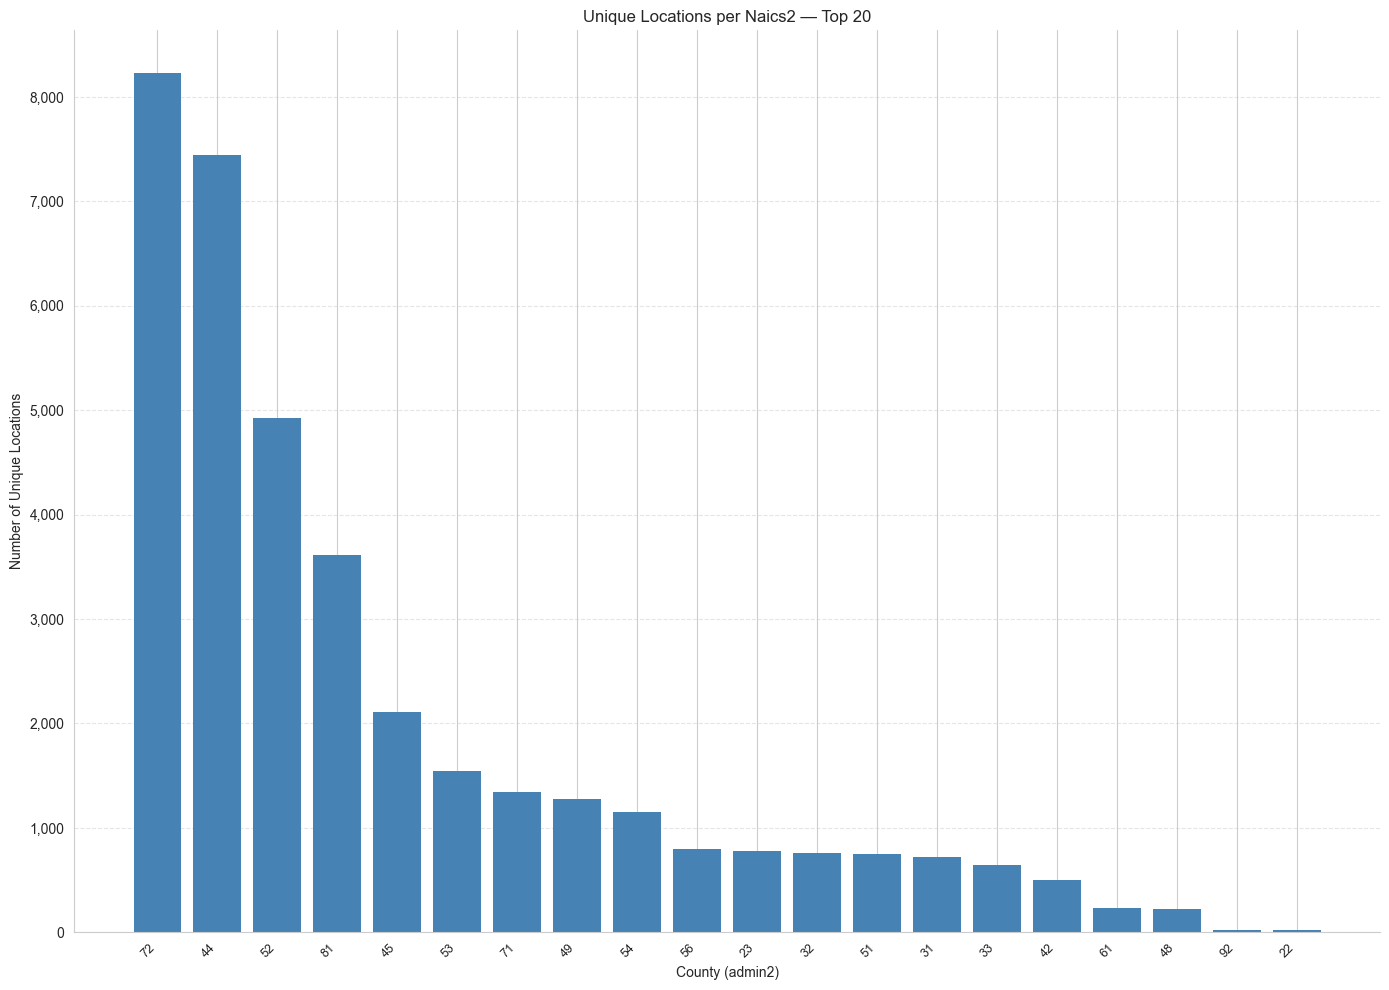

In [4]:
import matplotlib.pyplot as plt

top20 = (Synthetic.groupby('naics2')['lid']
         .nunique()
         .nlargest(20)
         .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(14, 10))

ax.bar(range(len(top20)), top20.values, color='steelblue', edgecolor='none')

ax.set_xticks(range(len(top20)))
ax.set_xticklabels(top20.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Number of Unique Locations')
ax.set_xlabel('County (admin2)')
ax.set_title('Unique Locations per Naics2 — Top 20')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

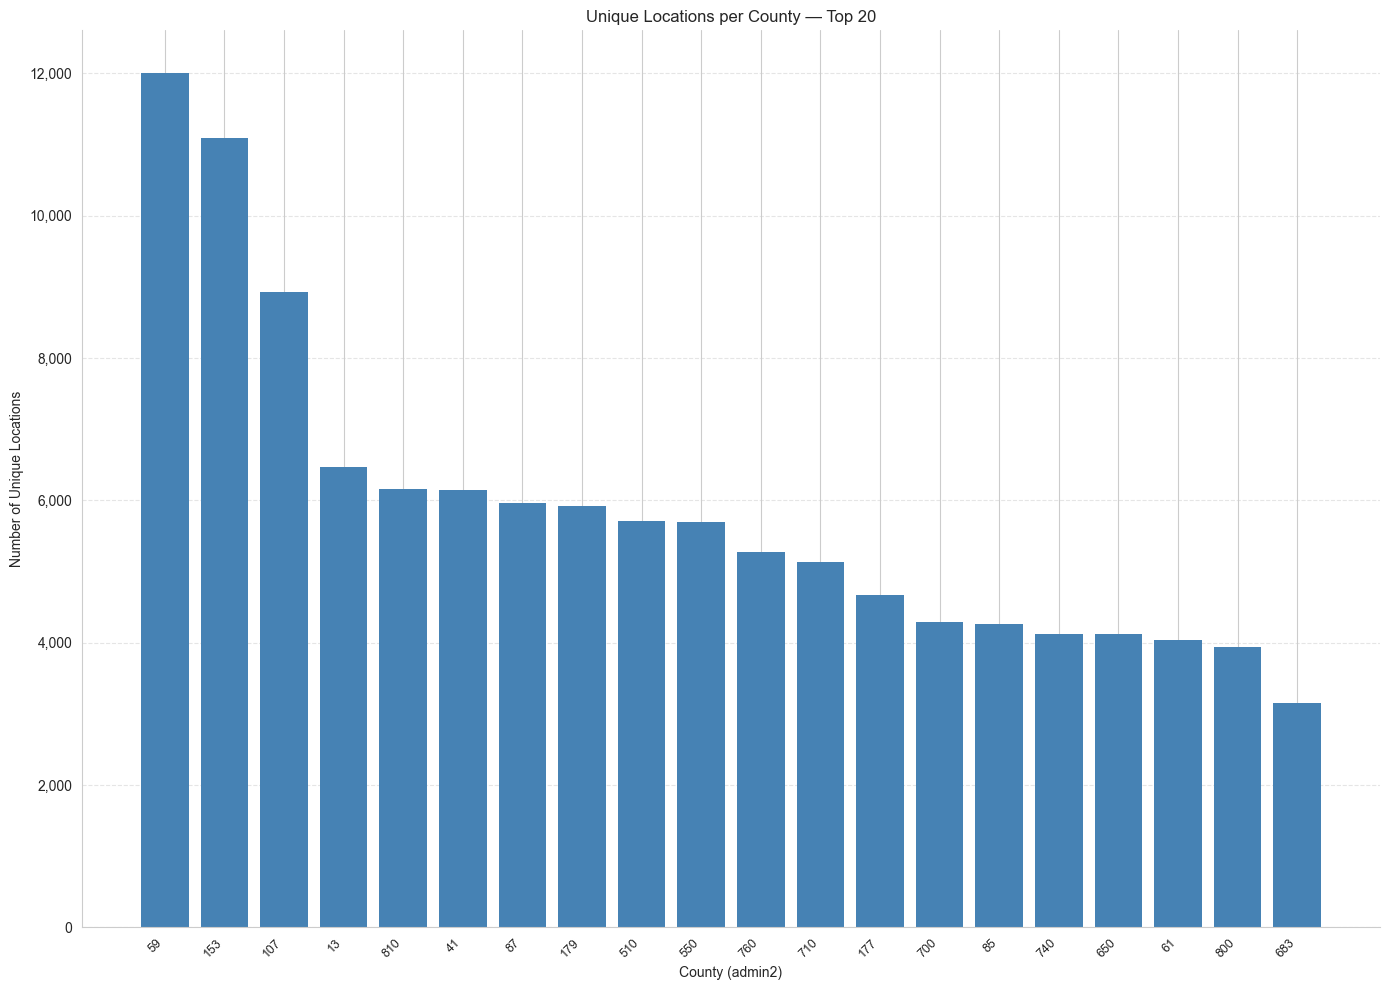

In [3]:
import matplotlib.pyplot as plt

top20 = (Synthetic.groupby('admin2')['lid']
         .nunique()
         .nlargest(20)
         .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(14, 10))

ax.bar(range(len(top20)), top20.values, color='steelblue', edgecolor='none')

ax.set_xticks(range(len(top20)))
ax.set_xticklabels(top20.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Number of Unique Locations')
ax.set_xlabel('County (admin2)')
ax.set_title('Unique Locations per County — Top 20')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Unique Synthetic locations in Charlottesville: 465


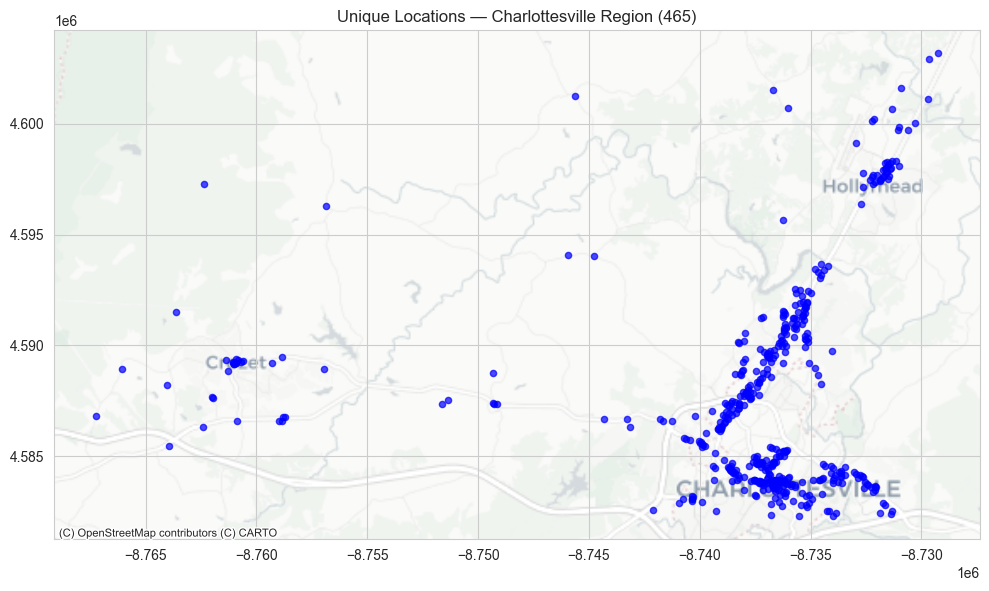

In [9]:
lat_min, lat_max = 38.02, 38.18
lon_min, lon_max = -78.76, -78.41

downtown = Synthetic[
    (Synthetic['latitude'].between(lat_min, lat_max)) &
    (Synthetic['longitude'].between(lon_min, lon_max))
].drop_duplicates(subset='loc_key')[['loc_key', 'latitude', 'longitude']]

print(f"Unique Synthetic locations in Charlottesville: {len(downtown)}")

gdf = gpd.GeoDataFrame(downtown, geometry=gpd.points_from_xy(downtown['longitude'], downtown['latitude']), crs='EPSG:4326').to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 8))
gdf.plot(ax=ax, color='blue', markersize=20, alpha=0.7)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title(f'Unique Locations — Charlottesville Region ({len(downtown)})')
plt.tight_layout()
plt.show()

Unique Synthetic locations in DC Metro (corrected): 4429


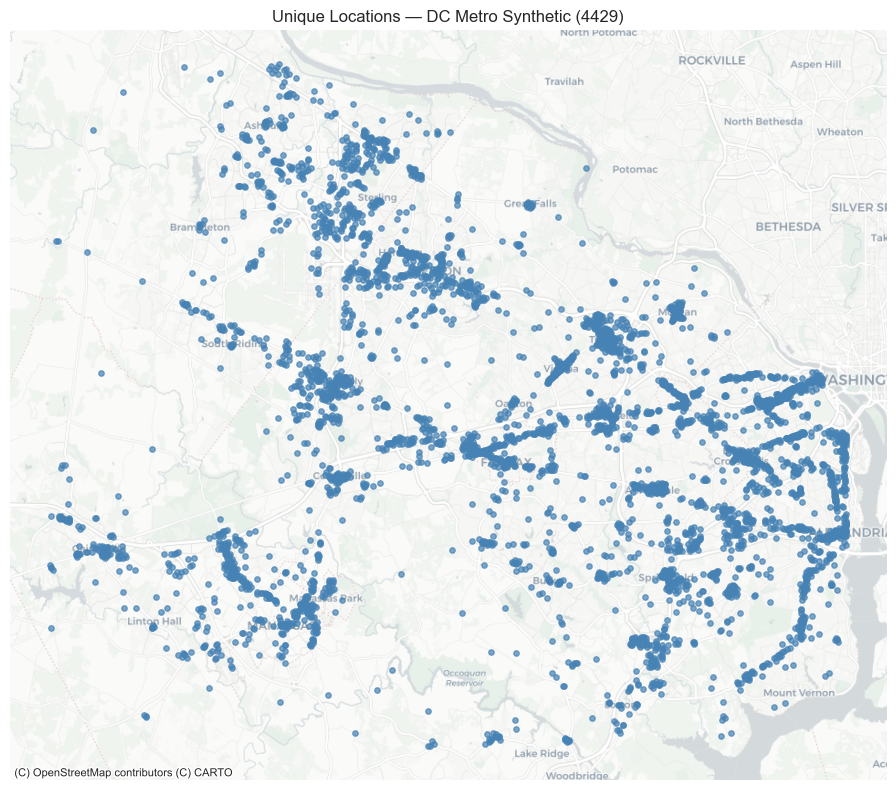

In [5]:
Synthetic['loc_key'] = (
    Synthetic['latitude'].round(4).astype(str) + '_' + Synthetic['longitude'].round(4).astype(str)
)

dc_syn = Synthetic[
    (Synthetic['latitude'].between(38.68, 39.08)) &
    (Synthetic['longitude'].between(-77.65, -77.05))
].drop_duplicates(subset='loc_key')[['loc_key', 'latitude', 'longitude']]

print(f"Unique Synthetic locations in DC Metro (corrected): {len(dc_syn)}")

gdf_dc_syn = gpd.GeoDataFrame(dc_syn, geometry=gpd.points_from_xy(dc_syn['longitude'], dc_syn['latitude']),
                               crs='EPSG:4326').to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 8))
gdf_dc_syn.plot(ax=ax, color='steelblue', markersize=15, alpha=0.7)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title(f'Unique Locations — DC Metro Synthetic ({len(dc_syn)})')
ax.set_axis_off()
plt.tight_layout()
plt.show()

Unique Synthetic locations in Richmond: 3997


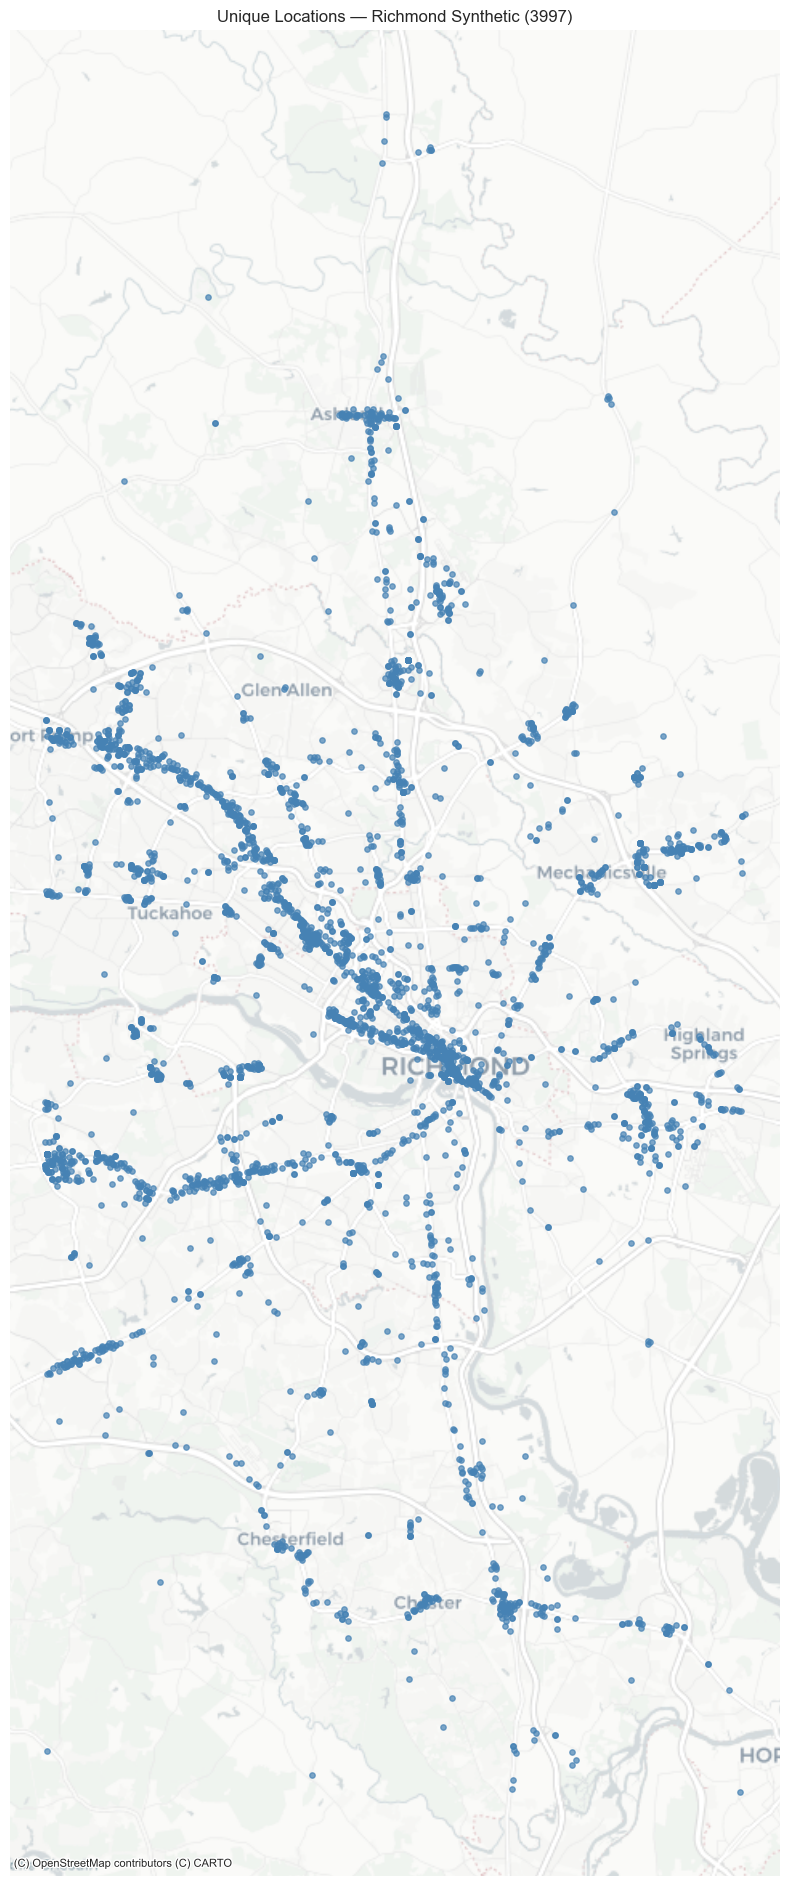

In [20]:
richmond_syn = Synthetic[
    (Synthetic['latitude'].between(37.29, 37.91)) &
    (Synthetic['longitude'].between(-77.61, -77.31))
].drop_duplicates(subset='lid')[['lid', 'latitude', 'longitude']]

print(f"Unique Synthetic locations in Richmond: {len(richmond_syn)}")

gdf_richmond_syn = gpd.GeoDataFrame(richmond_syn, geometry=gpd.points_from_xy(richmond_syn['longitude'], richmond_syn['latitude']),
                                     crs='EPSG:4326').to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 25))
gdf_richmond_syn.plot(ax=ax, color='steelblue', markersize=15, alpha=0.7)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title(f'Unique Locations — Richmond Synthetic ({len(richmond_syn)})')
ax.set_axis_off()
plt.tight_layout()
plt.show()

Unique Synthetic locations in Virginia Beach: 3575


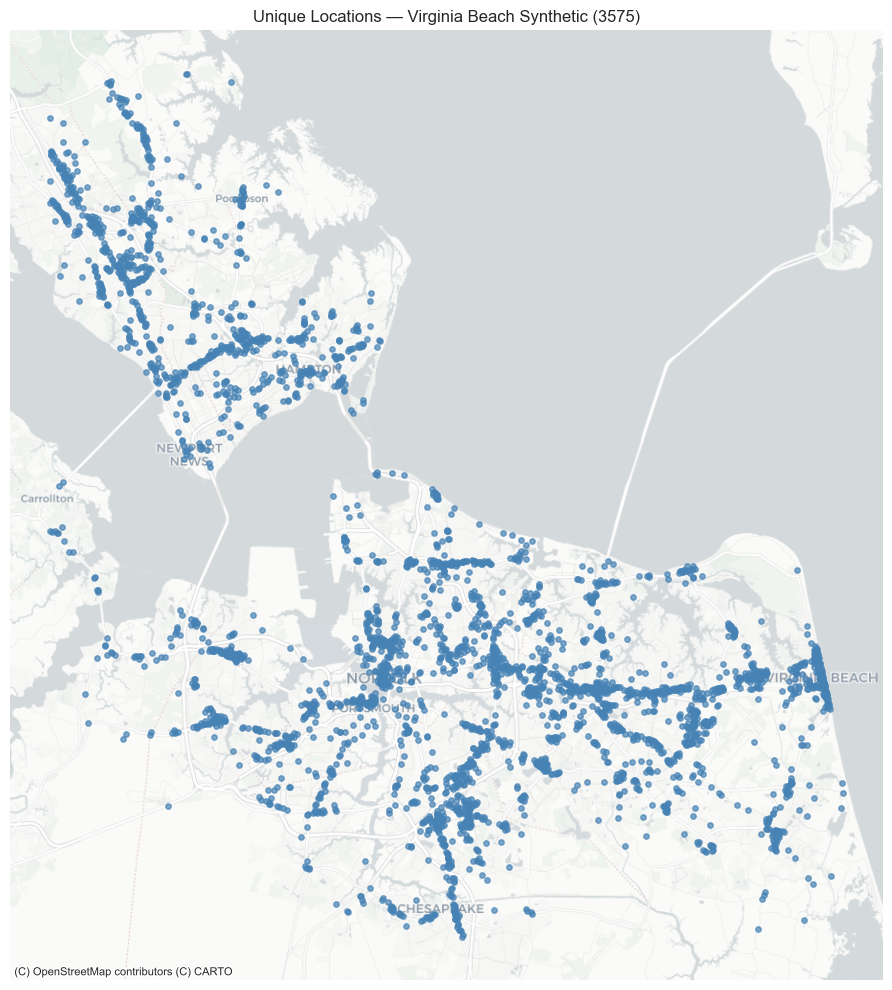

In [8]:
vb_syn = Synthetic[
    (Synthetic['latitude'].between(36.70, 37.20)) &
    (Synthetic['longitude'].between(-76.53, -75.95))
].drop_duplicates(subset='loc_key')[['loc_key', 'latitude', 'longitude']]

print(f"Unique Synthetic locations in Virginia Beach: {len(vb_syn)}")

gdf_vb_syn = gpd.GeoDataFrame(vb_syn, geometry=gpd.points_from_xy(vb_syn['longitude'], vb_syn['latitude']),
                               crs='EPSG:4326').to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))
gdf_vb_syn.plot(ax=ax, color='steelblue', markersize=15, alpha=0.7)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title(f'Unique Locations — Virginia Beach Synthetic ({len(vb_syn)})')
ax.set_axis_off()
plt.tight_layout()
plt.show()

Unique Synthetic locations in Roanoke: 609


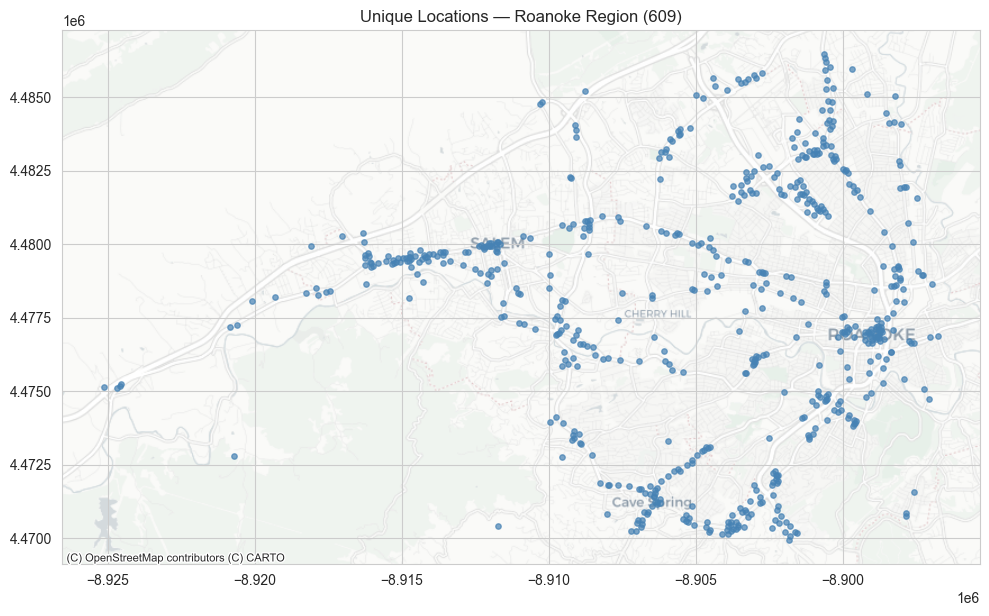

In [7]:
Synthetic['loc_key'] = (
    Synthetic['latitude'].round(4).astype(str) + '_' + Synthetic['longitude'].round(4).astype(str)
)

roanoke_syn = Synthetic[
    (Synthetic['latitude'].between(37.22, 37.34)) &
    (Synthetic['longitude'].between(-80.19, -79.92))
].drop_duplicates(subset='loc_key')[['loc_key', 'latitude', 'longitude']]

print(f"Unique Synthetic locations in Roanoke: {len(roanoke_syn)}")

gdf_roanoke_syn = gpd.GeoDataFrame(roanoke_syn, geometry=gpd.points_from_xy(roanoke_syn['longitude'], roanoke_syn['latitude']),
                                    crs='EPSG:4326').to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 8))
gdf_roanoke_syn.plot(ax=ax, color='steelblue', markersize=15, alpha=0.7)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title(f'Unique Locations — Roanoke Region ({len(roanoke_syn)})')
plt.tight_layout()
plt.show()

In [11]:
print(Synthetic['admin2'].dtype)
print(Synthetic['admin2'].unique()[:20])

int64
[131   1 810   3  15 125 540  31  41  65  79 109  29  87 137 790 820 163
  75 113]


In [12]:
print(Synthetic[Synthetic['admin2'].isin([770, 161])].shape)
print(sorted(Synthetic['admin2'].unique()))

(42892, 17)
[np.int64(1), np.int64(3), np.int64(5), np.int64(7), np.int64(9), np.int64(11), np.int64(13), np.int64(15), np.int64(17), np.int64(19), np.int64(21), np.int64(23), np.int64(25), np.int64(27), np.int64(29), np.int64(31), np.int64(33), np.int64(35), np.int64(36), np.int64(37), np.int64(41), np.int64(43), np.int64(45), np.int64(47), np.int64(49), np.int64(51), np.int64(53), np.int64(57), np.int64(59), np.int64(61), np.int64(63), np.int64(65), np.int64(67), np.int64(69), np.int64(71), np.int64(73), np.int64(75), np.int64(77), np.int64(79), np.int64(81), np.int64(83), np.int64(85), np.int64(87), np.int64(89), np.int64(91), np.int64(93), np.int64(95), np.int64(97), np.int64(99), np.int64(101), np.int64(103), np.int64(105), np.int64(107), np.int64(109), np.int64(111), np.int64(113), np.int64(115), np.int64(117), np.int64(119), np.int64(121), np.int64(125), np.int64(127), np.int64(131), np.int64(133), np.int64(135), np.int64(137), np.int64(139), np.int64(141), np.int64(143), np.int